# Visualization

In [ ]:
'''
- matplotlib
- seaborn
- plotly
'''

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
employee_name = ['Bob', 'Arthur', 'Bill', 'Dutch', 'Sadie']
salary = [20000, 30000, 10000, 40000, 35000]
bonus = [5000, 10000, 2000, 15000, 13570]

## Line Plot

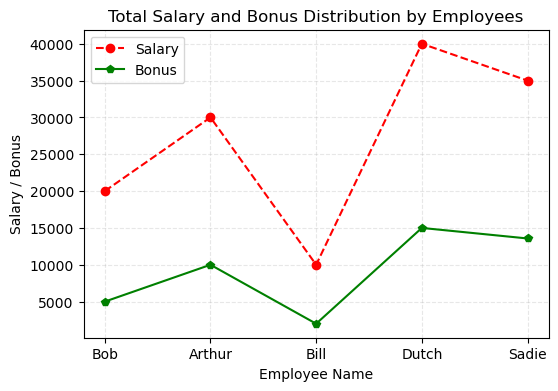

In [11]:
plt.figure(figsize=(6, 4)) # 600 x 400 pxl
plt.plot(employee_name, salary, color='red', marker='o', linestyle='--', label='Salary')
plt.plot(employee_name, bonus, color='green', marker='p', label='Bonus')
plt.xlabel('Employee Name')
plt.ylabel('Salary / Bonus')
plt.title('Total Salary and Bonus Distribution by Employees')
plt.grid(alpha=0.3, linestyle='dashed')
plt.legend()
plt.savefig('salary_bonus.png')
plt.show()

## Bar Plot

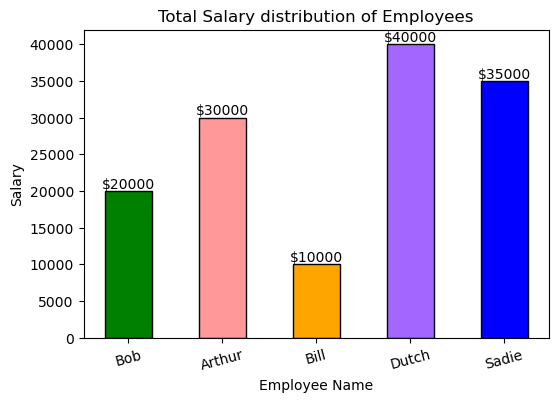

In [30]:
plt.figure(figsize=(6, 4))
plt.bar(employee_name, salary, color=['green', '#ff9999', 'orange', '#a366ff', 'blue'], width=0.5, edgecolor='black')
plt.xlabel('Employee Name')
plt.ylabel('Salary')
plt.title('Total Salary distribution of Employees')
plt.xticks(rotation=15)

# ha = 'left/right/center', va='top/bottom/center'
for idx, val in enumerate(salary):
    plt.text(idx, val, f'${val}', ha='center', va='bottom')

plt.show()

In [32]:
df = pd.read_csv('hr_cleaned_data.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Salary_Label,salary_label_num,PerformanceScore_id,HireDay_Name_id,E_FirstName,E_MiddleName,E_LastName,M_first_name,M_middle_name,M_last_name
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,Low Salary,0,0,0,Wilson,K,Adinolfi,Michael,NaN,Albert
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,Medium Salary,1,1,1,Karthikeyan,NaN,Ait Sidi,Simon,NaN,Roup
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,Low Salary,0,1,0,Sarah,NaN,Akinkuolie,Kissy,NaN,Sullivan
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,Low Salary,0,1,1,Trina,NaN,Alagbe,Elijiah,NaN,Gray
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,Low Salary,0,1,1,Carol,NaN,Anderson,Webster,NaN,Butler


## Pie Chart

In [33]:
perf_emp = df.groupby('PerformanceScore')['EmpID'].count().reset_index()
perf_emp

,PerformanceScore,EmpID
0,Exceeds,97
1,Fully Meets,454
2,Needs Improvement,18
3,PIP,13


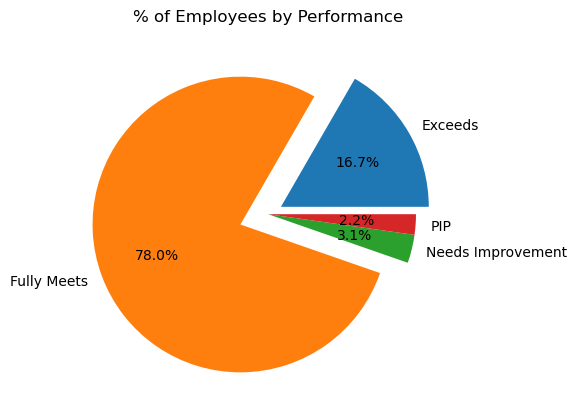

In [52]:
plt.pie(
    perf_emp['EmpID'],
    labels=perf_emp['PerformanceScore'],
    autopct = '%1.1f%%',
    explode = (0.1, 0.2, 0, 0)
)
plt.title('% of Employees by Performance')
plt.show()

## Donut Chart

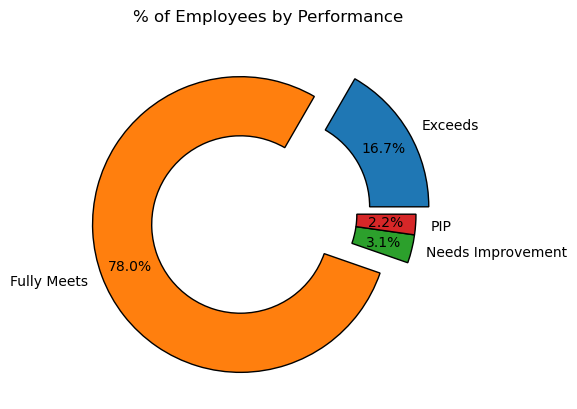

In [58]:
plt.pie(
    perf_emp['EmpID'],
    labels=perf_emp['PerformanceScore'],
    autopct = '%1.1f%%',
    # width edge properties
    wedgeprops = {'width': 0.4, 'edgecolor':'#000'},
    pctdistance=0.8,
    explode = (0.1, 0.2, 0, 0)
)
plt.title('% of Employees by Performance')
plt.show()

## Scatter Plot

In [59]:
temp = pd.read_csv('Dataset/temperature.csv')
temp.head()

,Temperature (°C),Humidity (%)
0,23.745401,57.186649
1,29.507143,66.765614
2,27.319939,64.034868
3,25.986585,60.921443
4,21.560186,49.099373


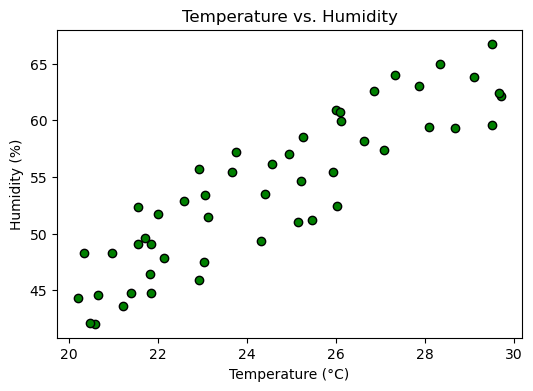

In [64]:
'''
- Both x-axis and y-axis values must be continuous.
'''
plt.figure(figsize=(6, 4))
plt.scatter(temp['Temperature (°C)'], temp['Humidity (%)'], color='green', edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs. Humidity')
plt.show()

## Correlation Data

In [ ]:
'''
- Pearson Correlation -> Data
- Spearsman Correlation

-- Only integer / float
'''

In [68]:
corr_columns = df.select_dtypes(['int', 'float'])
corr_columns = corr_columns.drop(columns=['EmpID', 'HireYear', 'HireMonth', 
                                          'HireDay', 'salary_label_num', 'PerformanceScore_id', 'HireDay_Name_id'])
# corr_columns

In [70]:
corr_data = corr_columns.corr()
# corr_data

<Axes: >

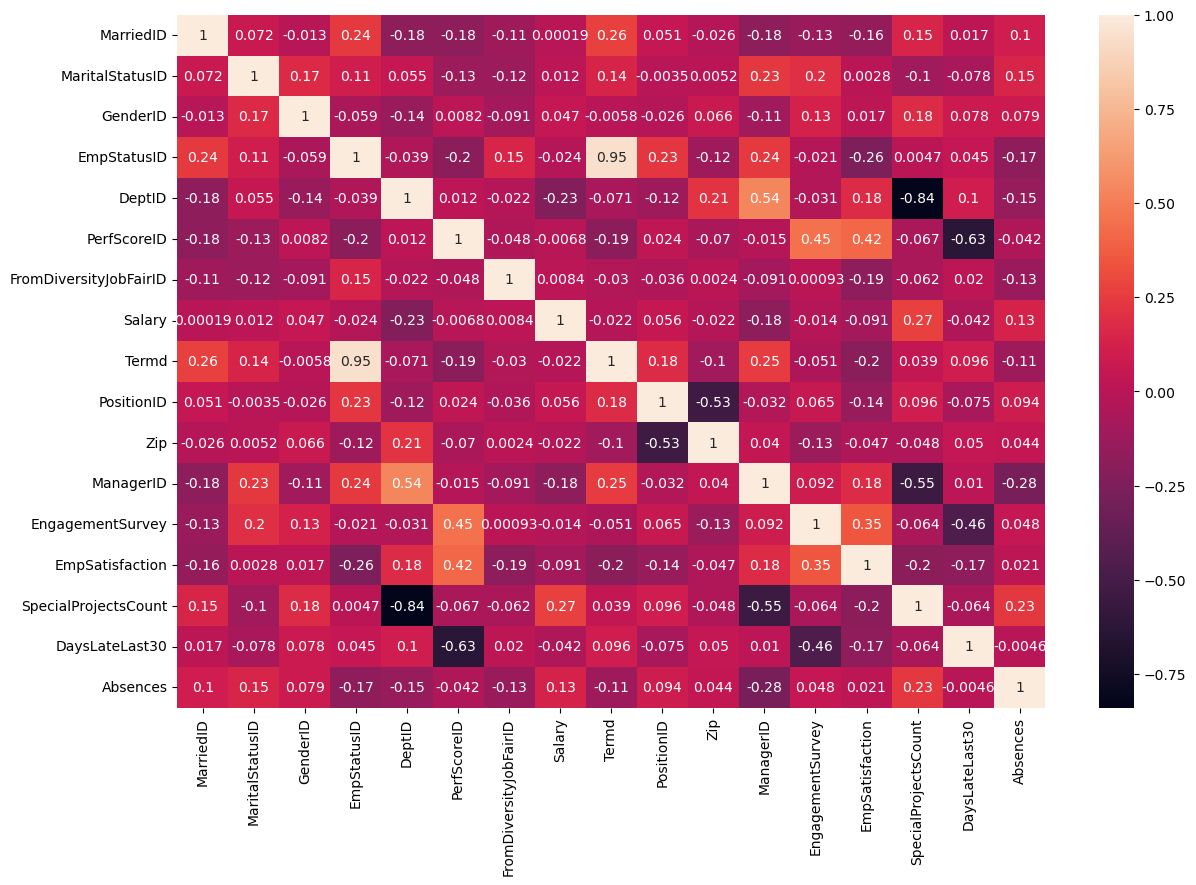

In [73]:
plt.figure(figsize=(14, 9))
sns.heatmap(corr_data, annot=True)